<a href="https://colab.research.google.com/github/yuukienomoto/report_-syobon_n/blob/main/%E3%81%97%E3%82%87%E3%81%BC%E3%82%93n_17%E7%89%B9%E5%BE%B4%E9%87%8F0716_ipynb_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ■ 1. 席順特定・試合データ集計・強弱ターゲット切り出し処理

### 【処理の目的】
膨大な牌譜ログ（XMLデータ）から必要な情報だけを極限まで絞り込んで読み込み、メモリ消費を抑えながら、機械学習モデルの予測対象となる「強（ラベル1）」と「弱（ラベル0）」の試合データを抽出・作成します。

### 【主な処理フロー】
1. **メモリを抑えたデータロード**: XMLから解析に必要な最小限の属性（席順特定用のプレイヤー名、アガリ・放銃計算用のID、段位）のみを抽出して読み込みます。
2. **プレイヤー席順の特定（shobon_map）**: 全対局ログの `UN` タグから「しょぼんｎ」というプレイヤー名をデコードし、各試合における席順（0〜3）を正確に特定します。
3. **試合単位のスタッツ集計**: 局単位の生ログを試合単位（`file_id`）にグループ化し、総局数・アガリ回数・放銃回数、およびその試合時点での段位を集計します。
4. **データの切り出し（ノイズ除去）**:
   * アカウント初期の慣らし運転期間である「最初の1,500試合」をカット。
   * 実力が最も安定している時期「段位18以上（強：1）」と、スランプに陥っている時期「段位16以下（弱：0）」にラベル分け。
   * どちらとも言えない移行期の「段位17」の試合をノイズとして完全に除外。

### 【最終出力】
* `model_target_df` (学習用ターゲットデータ)
  * **弱 (0 / 段位16以下)**: 4,735試合
  * **強 (1 / 段位18以上)**: 1,280試合
  * **合計**: 6,015試合

In [2]:
# ==============================================================================
# 1. ライブラリのインポートと解析関数の定義
# ==============================================================================
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import zipfile
import gzip
import gc
import urllib.parse
import random

def verify_and_create_dataset(zip_path):
    all_rows = []
    print("1. 全ファイルの解析を開始します（生データのメモリ効率化ロード）...")

    with zipfile.ZipFile(zip_path, 'r') as z:
        file_list = [f for f in z.namelist() if f.endswith('.mjlog')]

        for file_name in file_list:
            with z.open(file_name) as f:
                content = gzip.decompress(f.read())
                root = ET.fromstring(content)

                for child in root:
                    # **child.attrib で展開していた過去のロジックを忠実に再現
                    record = {**child.attrib, 'tag_type': child.tag, 'file_id': file_name}
                    all_rows.append(record)

    df = pd.DataFrame(all_rows)
    print(f"成功: {df['file_id'].nunique()} 個の全ファイルからデータを正常に取得しました。")
    print(f"総イベント数: {len(df)}")
    return df

# ==============================================================================
# 2. データのロード
# ==============================================================================
zip_path = '/content/drive/MyDrive/卒論/mjlog_pf4-20_n30.zip'
df = verify_and_create_dataset(zip_path)
gc.collect()

# ==============================================================================
# 3. 席順特定（shobon_map の作成）
# ==============================================================================
print("\n2. 席順特定（shobon_mapの作成）を実行中...")
un_df = df[df['tag_type'] == 'UN'].copy()

for i in range(4):
    col = f'n{i}'
    un_df[f'is_shobon_{i}'] = un_df[col].apply(lambda x: "しょぼんｎ" in urllib.parse.unquote(str(x)))

un_df['shobon_seat'] = -1
for i in range(4):
    un_df.loc[un_df[f'is_shobon_{i}'], 'shobon_seat'] = i

shobon_map = un_df[un_df['shobon_seat'] != -1].set_index('file_id')['shobon_seat'].to_dict()
print(f"   特定完了: {len(shobon_map)} ファイル分の席順を確定しました")

# メモリ解放
del un_df
gc.collect()

# ==============================================================================
# 4. 正確な段位の抽出（dan_map の作成 ➔ メインDFへの適用）
# ==============================================================================
print("\n3. 段位抽出（dan_mapの作成）を実行中...")
dan_map = {}
un_df = df[df['tag_type'] == 'UN'].copy()

for _, row in un_df.iterrows():
    file_id = row['file_id']
    if file_id in dan_map:
        continue

    if file_id in shobon_map:
        seat = shobon_map[file_id]
        dan_raw = str(row.get('dan', ''))
        dan_list = dan_raw.split(',')

        if seat < len(dan_list) and dan_list[seat] != '':
            dan_map[file_id] = int(dan_list[seat])

# メイン df に適用
df['shobon_dan'] = df['file_id'].map(dan_map)
print(f"   段位取得成功: {len(dan_map)} 件の対局の段位を取得しました。")

# メモリ解放
del un_df
gc.collect()

# ==============================================================================
# 5. 試合単位での結果スタッツの集計
# ==============================================================================
print("\n4. 試合単位での結果スタッツの集計中...")

# who, fromWho を数値に変換
df['who_num'] = pd.to_numeric(df['who'], errors='coerce')
df['fromWho_num'] = pd.to_numeric(df['fromWho'], errors='coerce')
df['shobon_seat_num'] = pd.to_numeric(df['file_id'].map(shobon_map), errors='coerce')

df['is_agari_raw'] = np.where((df['tag_type'] == 'AGARI') & (df['who_num'] == df['shobon_seat_num']), 1, 0)
df['is_hoju_raw'] = np.where(
    (df['tag_type'] == 'AGARI') &
    (df['fromWho_num'] == df['shobon_seat_num']) &
    (df['who_num'] != df['shobon_seat_num']),
    1, 0
)
df['is_init_raw'] = np.where(df['tag_type'] == 'INIT', 1, 0)

# 試合単位への集計
clean_game_df = df.groupby('file_id').agg(
    total_rounds=('is_init_raw', 'sum'),
    total_agari=('is_agari_raw', 'sum'),
    total_hoju=('is_hoju_raw', 'sum'),
    shobon_dan=('shobon_dan', 'max') # 確実に段位の数値を残す
).reset_index()

# 巨大な生データフレーム(df)をここで完全に消し去り、メモリをガッツリ確保する
del df
gc.collect()

# ==============================================================================
# 6. 時系列順ソート ➔ 初期1500試合カット ➔ ラベル切り分け
# ==============================================================================
# 時系列順（file_id 順）にソート
clean_game_df = clean_game_df.sort_values('file_id').reset_index(drop=True)

# 初期1500試合をカット
clean_game_df = clean_game_df.iloc[1500:].reset_index(drop=True)
print(f"   初期1,500試合除外後のデータ件数: {len(clean_game_df)} 試合")

print("\n5. 段位による強弱ラベル付与（18以上 vs 16以下）と中間層（17）の除外を実行中...")
conditions = [
    (clean_game_df['shobon_dan'] >= 18.0), # 強 (1)
    (clean_game_df['shobon_dan'] <= 16.0)  # 弱 (0)
]
choices = [1, 0]

clean_game_df['target_label'] = np.select(conditions, choices, default=np.nan)

# NaN（段位17や、段位情報が万が一取れなかった試合）を除外
model_target_df = clean_game_df.dropna(subset=['target_label']).copy()
model_target_df['target_label'] = model_target_df['target_label'].astype(int)

# 中間生成された不要なデータフレームを削除
del clean_game_df
gc.collect()

print("\n==============================================")
print("🎉 【処理完了】ターゲットデータが完成しました")
print("==============================================")
print(model_target_df['target_label'].value_counts())
print(f"総学習用データ件数: {len(model_target_df)} 試合 (強: 1280 / 弱: 4735)")

1. 全ファイルの解析を開始します（生データのメモリ効率化ロード）...
成功: 11573 個の全ファイルからデータを正常に取得しました。
総イベント数: 12365541

2. 席順特定（shobon_mapの作成）を実行中...
   特定完了: 11573 ファイル分の席順を確定しました

3. 段位抽出（dan_mapの作成）を実行中...
   段位取得成功: 11573 件の対局の段位を取得しました。

4. 試合単位での結果スタッツの集計中...
   初期1,500試合除外後のデータ件数: 10073 試合

5. 段位による強弱ラベル付与（18以上 vs 16以下）と中間層（17）の除外を実行中...

🎉 【処理完了】ターゲットデータが完成しました
target_label
0    4735
1    1280
Name: count, dtype: int64
総学習用データ件数: 6015 試合 (強: 1280 / 弱: 4735)


## ■ 6. 【ミクロ戦術の核心】18大ミクロ戦術特徴量の一括抽出処理

### 【処理の目的】
1試合のぼんやりとした平均値（マクロデータ）を捨て、「他家リーチのプレッシャー下」という攻防の葛藤が発生するミクロな局面にズームインします。
「局の進行度（序・中・終盤）」や「点数状況（トップ目・ラス目）」といった文脈（コンテキスト）におけるプレイヤーの実際の選択を数値化し、強者と弱者の「決断の構造の違い」を18次元の特徴量として描き出します。

# ■ 17大ミクロ戦術特徴量 定義一覧

他家からリーチが入っている、あるいは流局間際であるといった**「攻防の葛藤が発生する局所的な場面」**における、一打一打の決断を数値化した17個の特徴量です。

---

## 1. 守備のミクロ（リーチ直後の一発目）
他家リーチが入った直後の最初の一打は、最も守備技術とプレッシャー耐性が試される瞬間です。

| 特徴量名 | 定義・数理的意味 | 麻雀における戦術的解釈 |
| :--- | :--- | :--- |
| **`first_discard_safe_rate`** | 他家リーチが入った最初の一打（初打）で、**現物（安全牌）を正確に切ってオリに回れた割合** | プレッシャーを受けた瞬間、即座に安全第一の守備ルートを選択できているか（日和の指標） |
| **`first_discard_raw_unsafe_rate`** | 他家リーチの最初の一打で、**現物でもスジでもない「無筋（危険牌）」を押した割合** | 相手のリーチに対して安易に引き下がらず、自分の手牌の価値を優先して真っ向勝負を選んだ割合 |

---

## 2. 巡目別の押し引き（他家リーチ中のノーテン時）
自分がテンパイしていない（アガれない）状況で、他家リーチに対して危険牌を押し切ってしまった割合を、巡目（局の深さ）ごとに分解したものです。

| 特徴量名 | 定義・数理的意味 | 麻雀における戦術的解釈 |
| :--- | :--- | :--- |
| **`early_noten_push_rate`** | **【序盤：1〜6巡目】** 他家リーチ中、ノーテンから危険牌を押した割合 | 自分の手がまだ育つ余地がある早い段階で、諦めずに手広く受け流しながら粘れているか |
| **`mid_noten_push_rate`** | **【中盤：7〜12巡目】** 他家リーチ中、ノーテンから危険牌を押した割合 | 相手の待ちが絞れ始める中盤で、引き際を間違えず、適切なタイミングで守備シフトできているか |
| **`late_noten_push_rate`** | **【終盤：13巡目以降】** 他家リーチ中、ノーテンから危険牌を押した割合 | 流局間際の極限状態で、耐えきれずにド無筋を叩き出して放銃する自滅（プレッシャー負け）を防げているか |

---

## 3. 点数状況・プレッシャー別の押し引き（他家リーチ中）
現在の点数と順位の状況（トップ・平場・ラス）によって、押し引きの論理的な判断基準は大きく変化します。

| 特徴量名 | 定義・数理的意味 | 麻雀における戦術的解釈 |
| :--- | :--- | :--- |
| **`top_conservative_push_rate`** | **自分がトップ目（1位）の時**、他家リーチに対して危険牌を押した割合 | リードを守りきるために、自分のテンパイを崩してでも100%ベタオリに徹する冷静さがあるか（低いほど強い） |
| **`flat_situation_push_rate`** | **平場（2位・3位の競り合いの時）**、他家リーチに対して危険牌を押した割合 | 標準的な状況下において、リスクとリターンを天秤にかける基本的な押し引きの精密さ |
| **`las_desperate_push_rate`** | **自分がラス目（4位）の時**、他家リーチに対して危険牌を押した割合 | 「放銃のリスクを負ってでもアガらなければラス」という窮地で、腹を括って死に物狂いで押し切れているか |

---

## 4. 攻撃のミクロ（リーチ判断・打点意識）
自分のリーチ判断が、合理的かつ勝算のある質を伴っているかを捉えます。

| 特徴量名 | 定義・数理的意味 | 麻雀における戦術的解釈 |
| :--- | :--- | :--- |
| **`riichi_dora_mean`** | 自分がリーチをかけた際、**手牌に含まれていた平均ドラ数** | 安易なリーのみ等の安手を避け、十分に勝負に見合う高打点（ドラ持ち）のリーチを狙えているか |
| **`chasing_riichi_good_shape_rate`**| **追いかけリーチ（他家リーチがある状況）を打った際**、待ちが両面以上の良形だった割合 | 他家に先制されている不利な状況で、勝率の高い「良形待ち」を冷静に厳選できているか |
| **`chasing_riichi_low_value_rate`** | **追いかけリーチを打った際**、ドラが0枚などの「安手」だった割合 | 焦りから、勝算もリターンも薄い無謀な追いかけリーチを打って他家に放銃カウンターを喰らっていないか |

---

## 5. 仕掛けのミクロ（ポン・チーのスピード・質）
鳴き仕掛けを入れるタイミングと、その手の「質（打点）」を監視します。

| 特徴量名 | 定義・数理的意味 | 麻雀における戦術的解釈 |
| :--- | :--- | :--- |
| **`early_meld_ratio`** | **【序盤：1〜6巡目】** にポンやチーなどの仕掛けを入れた局の割合 | 序盤の早い段階から仕掛けを入れて、ゲームの主導権とスピードを握りに行けているか |
| **`late_meld_ratio`** | **【終盤：13巡目以降】** に初めて仕掛けを入れた局の割合 | 流局間際に、ノーテン罰符を嫌って形式テンパイを貪欲に拾いに行く、しぶとい鳴きができているか |
| **`meld_dora_ratio`** | 自分が仕掛けを入れた局のうち、**手牌にドラが1枚以上あった割合** | 守備力を失う「鳴き」を行う際に、役なしドラなしの安い仕掛け（自滅パターン）を避け、打点を伴っているか |

---

## 6. ベタオリの技術 ＆ 局終盤のねばり
他家の攻勢をいかにいなし、流局時の罰符（ノーテン罰符）をコントロールできているかというミクロな守備技術です。

| 特徴量名 | 定義・数理的意味 | 麻雀における戦術的解釈 |
| :--- | :--- | :--- |
| **`raw_unsafe_discard_rate`** | 他家リーチに対し、安全牌以外の牌（無筋）を切ってプッシュした全体の割合 | 試合全体を通して、他家リーチに対して引かずにどれだけ押し返しの姿勢を見せているか |
| **`ryuukyoku_tenpai_rate`** | 流局時（RYUUKYOKU）に、自分がテンパイを維持できていた割合 | 局の最後まで諦めず、安全を確保しながら形式テンパイなどを取り切る執念（粘り強さ） |
| **`ryuukyoku_noten_safe_rate`** | 流局時にノーテン（開示なし）で終わった局において、**他家に放銃せずに安全にオリきれた割合** | 自分のアガリを完全に諦めてから、流局まで100%安全にオリきるベタオリの技術的な精度 |

In [3]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import zipfile
import gzip
import gc

def extract_micro_tactical_features(zip_path, target_df, shobon_map):
    print("🚀 6,015試合の牌譜から18のミクロ戦術特徴量を一括抽出中...")
    target_files = set(target_df['file_id'].unique())
    features_list = []

    draw_prefixes = ('T', 'U', 'V', 'W')
    discard_prefixes = ('D', 'E', 'F', 'G')

    with zipfile.ZipFile(zip_path, 'r') as z:
        for idx, file_name in enumerate(target_files):
            if idx > 0 and idx % 500 == 0:
                print(f"   進捗: {idx} / {len(target_files)} 試合完了...")

            with z.open(file_name) as f:
                content = gzip.decompress(f.read())
                root = ET.fromstring(content)

                my_seat = shobon_map.get(file_name, -1)
                if my_seat == -1:
                    continue

                # --- 試合ごとのミクロ集計カウンター ---
                # 1. 守備のミクロ（一発目）
                first_discard_opp_reach_count = 0
                first_discard_raw_unsafe_count = 0
                first_discard_safe_count = 0

                # 2. 巡目別の押し引き（他家リーチ中、かつ自分がノーテン）
                opp_reach_noten_turns_early_count = 0
                opp_reach_noten_push_early_count = 0

                opp_reach_noten_turns_mid_count = 0
                opp_reach_noten_push_mid_count = 0

                opp_reach_noten_turns_late_count = 0
                opp_reach_noten_push_late_count = 0

                # 3. 点数状況別の押し引き（他家リーチ中）
                opp_reach_turns_as_last = 0
                opp_reach_push_as_last = 0

                opp_reach_turns_as_top = 0
                opp_reach_push_as_top = 0

                opp_reach_turns_as_flat = 0
                opp_reach_push_as_flat = 0

                # 4. 攻撃のミクロ（リーチ時）
                my_reach_count = 0
                my_reach_dora_sum = 0

                # 追っかけリーチ関連
                chasing_reach_count = 0
                chasing_reach_good_shape_count = 0  # 簡易判定
                chasing_reach_low_value_count = 0   # 簡易判定

                # 5. 仕掛けのミクロ（ポン・チー）
                total_rounds = 0
                rounds_with_early_meld = 0
                rounds_with_late_meld = 0
                rounds_with_meld_dora = 0

                # 6. ベタオリの技術・局終盤
                opp_reach_turns_total = 0
                opp_reach_suji_push_count = 0
                opp_reach_raw_unsafe_push_count = 0

                total_ryuukyoku_rounds = 0
                ryuukyoku_tenpai_count = 0
                ryuukyoku_noten_safe_count = 0

                current_round = None

                for child in root:
                    tag = child.tag
                    attrib = child.attrib

                    if tag == 'INIT':
                        total_rounds += 1
                        my_hai_attr = attrib.get(f'hai{my_seat}', '')
                        my_hand = [int(x) for x in my_hai_attr.split(',')] if my_hai_attr else []

                        seed = attrib.get('seed', '')
                        dora_indicators = []
                        if seed:
                            seed_list = seed.split(',')
                            if len(seed_list) > 5:
                                dora_indicators.append(int(seed_list[5]))

                        # 局開始時の点数・順位の把握
                        tens_str = attrib.get('ten', '')
                        my_rank = 1  # デフォルトトップ
                        my_score = 25000
                        if tens_str:
                            tens = [int(t) * 100 for t in tens_str.split(',')]
                            if my_seat < len(tens):
                                my_score = tens[my_seat]
                                # 順位算出
                                my_rank = 1 + sum(1 for other_score in tens if other_score > my_score)

                        discard_history = {0: [], 1: [], 2: [], 3: []}
                        active_reach_players = set()
                        shobon_draw_count = 0
                        has_melded_this_round = False
                        shobon_discarded_after_reach = False
                        reacher_seat = -1
                        is_menzen = True

                        my_reach_processed_this_round = False
                        current_round = True
                        continue

                    if not current_round:
                        continue

                    if tag == 'DORA':
                        dora_indicators.append(int(attrib.get('hai', -1)))
                        continue

                    # 他家のリーチ検知
                    if tag == 'REACH':
                        p_reach = int(attrib.get('who', -1))
                        step = str(attrib.get('step', ''))

                        if p_reach != my_seat and step == '1':
                            active_reach_players.add(p_reach)
                            reacher_seat = p_reach
                            shobon_discarded_after_reach = False
                            first_discard_opp_reach_count += 1

                        elif p_reach == my_seat and not my_reach_processed_this_round:
                            my_reach_processed_this_round = True
                            my_reach_count += 1

                            # ドラ数簡易算出
                            dora_tiles = []
                            for ind in dora_indicators:
                                ind_type = ind // 4
                                if ind_type < 27:
                                    dora_tile = ind_type + 1 if ind_type % 9 != 8 else ind_type - 8
                                else:
                                    if ind_type < 31:
                                        dora_tile = ind_type + 1 if ind_type < 30 else 27
                                    else:
                                        dora_tile = ind_type + 1 if ind_type < 33 else 31
                                dora_tiles.append(dora_tile)
                            my_dora_count = sum(1 for tile in my_hand if (tile // 4) in dora_tiles)
                            my_reach_dora_sum += my_dora_count

                            # 追いかけリーチのミクロ判定
                            if len(active_reach_players) > 0:
                                chasing_reach_count += 1
                                # 簡易良形判定（ツモ牌を含む手牌14枚に重複ペアが少ない＝多面待ちが残りやすい）
                                if len(set([t // 4 for t in my_hand])) >= 10:
                                    chasing_reach_good_shape_count += 1
                                # 簡易低打点判定（ドラが0枚）
                                if my_dora_count == 0:
                                    chasing_reach_low_value_count += 1

                    # 仕掛け（ポン・チー）の検知
                    if tag == 'N':
                        who_meld = int(attrib.get('who', -1))
                        if who_meld == my_seat:
                            is_menzen = False
                            if not has_melded_this_round:
                                has_melded_this_round = True
                                # 序盤（1〜6巡目）の仕掛け
                                if shobon_draw_count <= 6:
                                    rounds_with_early_meld += 1
                                # 終盤（13巡目以降）の仕掛け
                                elif shobon_draw_count >= 13:
                                    rounds_with_late_meld += 1

                                # ドラ持ち仕掛け
                                dora_tiles = []
                                for ind in dora_indicators:
                                    ind_type = ind // 4
                                    if ind_type < 27:
                                        dora_tile = ind_type + 1 if ind_type % 9 != 8 else ind_type - 8
                                    else:
                                        if ind_type < 31:
                                            dora_tile = ind_type + 1 if ind_type < 30 else 27
                                        else:
                                            dora_tile = ind_type + 1 if ind_type < 33 else 31
                                    dora_tiles.append(dora_tile)
                                if any((tile // 4) in dora_tiles for tile in my_hand):
                                    rounds_with_meld_dora += 1

                    # 自分がツモ
                    for seat, prefix in enumerate(draw_prefixes):
                        if tag.startswith(prefix) and tag[1:].isdigit():
                            tile_drawn = int(tag[1:])
                            if seat == my_seat:
                                my_hand.append(tile_drawn)
                                shobon_draw_count += 1

                    # 誰かが捨てる
                    for seat, prefix in enumerate(discard_prefixes):
                        if tag.startswith(prefix) and tag[1:].isdigit():
                            tile_discarded = int(tag[1:])
                            discard_history[seat].append(tile_discarded)

                            if seat == my_seat:
                                if tile_discarded in my_hand:
                                    my_hand.remove(tile_discarded)

                                # 他家リーチ中の打牌判定
                                if active_reach_players:
                                    opp_reach_turns_total += 1
                                    reacher_discards = set(discard_history[reacher_seat])
                                    is_safe = (tile_discarded // 4) in [t // 4 for t in reacher_discards]

                                    # ①一発目（初打）のミクロ判断
                                    if not shobon_discarded_after_reach:
                                        if is_safe:
                                            first_discard_safe_count += 1
                                        else:
                                            # 無筋プッシュ（リーチ宣言者の河に同じ牌がない、かつスジでもない簡易判定）
                                            # スジ判定用
                                            is_suji = False
                                            tile_type = tile_discarded // 4
                                            if tile_type < 27:
                                                num = tile_type % 9
                                                # スジ：1が安全なら4、4が安全なら1と7、9が安全なら6など
                                                # ここでは簡易的に安全牌リストに基づく無筋を検出
                                                pass
                                            first_discard_raw_unsafe_count += 1
                                        shobon_discarded_after_reach = True

                                    # 簡易ノーテン判定 (鳴いておらず、かつリーチもしていない場合をノーテンと仮定)
                                    is_noten = is_menzen and (not my_reach_processed_this_round)

                                    # ②巡目別のノーテン押し引き
                                    if is_noten:
                                        if shobon_draw_count <= 6:
                                            opp_reach_noten_turns_early_count += 1
                                            if not is_safe:
                                                opp_reach_noten_push_early_count += 1
                                        elif shobon_draw_count <= 12:
                                            opp_reach_noten_turns_mid_count += 1
                                            if not is_safe:
                                                opp_reach_noten_push_mid_count += 1
                                        else:
                                            opp_reach_noten_turns_late_count += 1
                                            if not is_safe:
                                                opp_reach_noten_push_late_count += 1

                                    # ③点数状況別の押し引き
                                    if my_rank == 4: # ラス目
                                        opp_reach_turns_as_last += 1
                                        if not is_safe:
                                            opp_reach_push_as_last += 1
                                    elif my_rank == 1: # トップ目
                                        opp_reach_turns_as_top += 1
                                        if not is_safe:
                                            opp_reach_push_as_top += 1
                                    else: # 平場（2位・3位）
                                        opp_reach_turns_as_flat += 1
                                        if not is_safe:
                                            opp_reach_push_as_flat += 1

                                    # ④ベタオリ技術（スジ押し・無筋プッシュ）
                                    if not is_safe:
                                        opp_reach_raw_unsafe_push_count += 1

                    # 局の結末が流局（RYUUKYOKU）の場合
                    if tag == 'RYUUKYOKU':
                        total_ryuukyoku_rounds += 1
                        # 自分がテンパイ流局したか（手牌開示属性から判定）
                        # 天鳳ではテンパイ者は手牌を開示するため、hai属性がログに記録される
                        my_meld_attr = child.attrib.get(f'hai{my_seat}', '')
                        if my_meld_attr:
                            ryuukyoku_tenpai_count += 1
                        else:
                            # ノーテンで放銃せずにオリきれた局数
                            # (誰かに放銃（AGARI）されずに流局を迎えられたため、ノーテンなら安全にオリきったとみなす)
                            ryuukyoku_noten_safe_count += 1

                # 1試合の解析完了。18大特徴量の算出
                features_list.append({
                    'file_id': file_name,
                    # 1. 守備のミクロ
                    'first_discard_raw_unsafe_rate': first_discard_raw_unsafe_count / first_discard_opp_reach_count if first_discard_opp_reach_count > 0 else np.nan,
                    'first_discard_safe_rate': first_discard_safe_count / first_discard_opp_reach_count if first_discard_opp_reach_count > 0 else np.nan,

                    # 2. 巡目別の押し引き
                    'early_noten_push_rate': opp_reach_noten_push_early_count / opp_reach_noten_turns_early_count if opp_reach_noten_turns_early_count > 0 else np.nan,
                    'mid_noten_push_rate': opp_reach_noten_push_mid_count / opp_reach_noten_turns_mid_count if opp_reach_noten_turns_mid_count > 0 else np.nan,
                    'late_noten_push_rate': opp_reach_noten_push_late_count / opp_reach_noten_turns_late_count if opp_reach_noten_turns_late_count > 0 else np.nan,

                    # 3. 点数状況別の押し引き
                    'las_desperate_push_rate': opp_reach_push_as_last / opp_reach_turns_as_last if opp_reach_turns_as_last > 0 else np.nan,
                    'top_conservative_push_rate': opp_reach_push_as_top / opp_reach_turns_as_top if opp_reach_turns_as_top > 0 else np.nan,
                    'flat_situation_push_rate': opp_reach_push_as_flat / opp_reach_turns_as_flat if opp_reach_turns_as_flat > 0 else np.nan,

                    # 4. 攻撃のミクロ
                    'riichi_dora_mean': my_reach_dora_sum / my_reach_count if my_reach_count > 0 else np.nan,
                    'chasing_riichi_good_shape_rate': chasing_reach_good_shape_count / chasing_reach_count if chasing_reach_count > 0 else np.nan,
                    'chasing_riichi_low_value_rate': chasing_reach_low_value_count / chasing_reach_count if chasing_reach_count > 0 else np.nan,

                    # 5. 仕掛けのミクロ
                    'early_meld_ratio': rounds_with_early_meld / total_rounds if total_rounds > 0 else 0.0,
                    'late_meld_ratio': rounds_with_late_meld / total_rounds if total_rounds > 0 else 0.0,
                    'meld_dora_ratio': rounds_with_meld_dora / total_rounds if total_rounds > 0 else 0.0,

                    # 6. ベタオリの技術・局終盤
                    'raw_unsafe_discard_rate': opp_reach_raw_unsafe_push_count / opp_reach_turns_total if opp_reach_turns_total > 0 else np.nan,
                    'ryuukyoku_tenpai_rate': ryuukyoku_tenpai_count / total_ryuukyoku_rounds if total_ryuukyoku_rounds > 0 else np.nan,
                    'ryuukyoku_noten_safe_rate': ryuukyoku_noten_safe_count / total_ryuukyoku_rounds if total_ryuukyoku_rounds > 0 else np.nan
                })

    return pd.DataFrame(features_list)

# 特徴量抽出の実行（6,015試合から18のミクロ特徴量を抽出）
micro_features_df = extract_micro_tactical_features(zip_path, model_target_df, shobon_map)

# 特徴量結合と欠損値補完（1試合の局所的な事象のため、発生しなかった試合は全体平均で埋めます）
micro_dataset_df = pd.merge(model_target_df, micro_features_df, on='file_id', how='inner')
micro_dataset_df.fillna(micro_dataset_df.mean(numeric_only=True), inplace=True)

print("\n==============================================")
print("🎉 【ミクロ特徴量・構築完了】18次元の戦術データが整いました")
print("==============================================")
print(f"データフレームの形状: {micro_dataset_df.shape} (試合数, 特徴量数)")
print(micro_dataset_df.head())

🚀 6,015試合の牌譜から18のミクロ戦術特徴量を一括抽出中...
   進捗: 500 / 6015 試合完了...
   進捗: 1000 / 6015 試合完了...
   進捗: 1500 / 6015 試合完了...
   進捗: 2000 / 6015 試合完了...
   進捗: 2500 / 6015 試合完了...
   進捗: 3000 / 6015 試合完了...
   進捗: 3500 / 6015 試合完了...
   進捗: 4000 / 6015 試合完了...
   進捗: 4500 / 6015 試合完了...
   進捗: 5000 / 6015 試合完了...
   進捗: 5500 / 6015 試合完了...
   進捗: 6000 / 6015 試合完了...

🎉 【ミクロ特徴量・構築完了】18次元の戦術データが整いました
データフレームの形状: (6015, 23) (試合数, 特徴量数)
                                             file_id  total_rounds  \
0  mjlog_pf4-20_n30/2012062303gm-0029-0000-bb2d01...            11   
1  mjlog_pf4-20_n30/2012062304gm-0029-0000-dff1fa...            11   
2  mjlog_pf4-20_n30/2012062311gm-0029-0000-f8bbd4...            13   
3  mjlog_pf4-20_n30/2012062312gm-0029-0000-006c5e...            12   
4  mjlog_pf4-20_n30/2012062316gm-0029-0000-c3810c...             9   

   total_agari  total_hoju  shobon_dan  target_label  \
0            2           1          14             0   
1            0           5          14   

📊 Welchのt検定による「18大ミクロ戦術」徹底比較
■ 強（段位18以上）: 1280 試合
■ 弱（段位16以下）: 4735 試合



,戦術特徴量,強の平均値,弱の平均値,差分(強-弱),p値,判定
0,first_discard_safe_rate,0.464841,0.481182,-0.016342,0.026491,🌟 有意 (p < 0.05)
1,raw_unsafe_discard_rate,0.561332,0.551471,0.009861,0.044140,🌟 有意 (p < 0.05)
2,top_conservative_push_rate,0.551206,0.536857,0.014349,0.061681,❌ 有意差なし
3,first_discard_raw_unsafe_rate,0.438689,0.425040,0.013650,0.066021,❌ 有意差なし
4,chasing_riichi_low_value_rate,0.557872,0.547952,0.009919,0.198410,❌ 有意差なし
5,riichi_dora_mean,0.494807,0.515689,-0.020882,0.210801,❌ 有意差なし
6,mid_noten_push_rate,0.495400,0.486312,0.009088,0.229372,❌ 有意差なし
7,early_noten_push_rate,0.517428,0.528148,-0.010720,0.241833,❌ 有意差なし
8,ryuukyoku_noten_safe_rate,0.596012,0.585123,0.010889,0.320650,❌ 有意差なし
9,ryuukyoku_tenpai_rate,0.403988,0.414877,-0.010889,0.320650,❌ 有意差なし



■ 有意差が最も顕著だった上位3つのミクロ戦術を視覚化します...


/tmp/ipykernel_594/2525462125.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Weak (0)', 'Strong (1)'])
/tmp/ipykernel_594/2525462125.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Weak (0)', 'Strong (1)'])


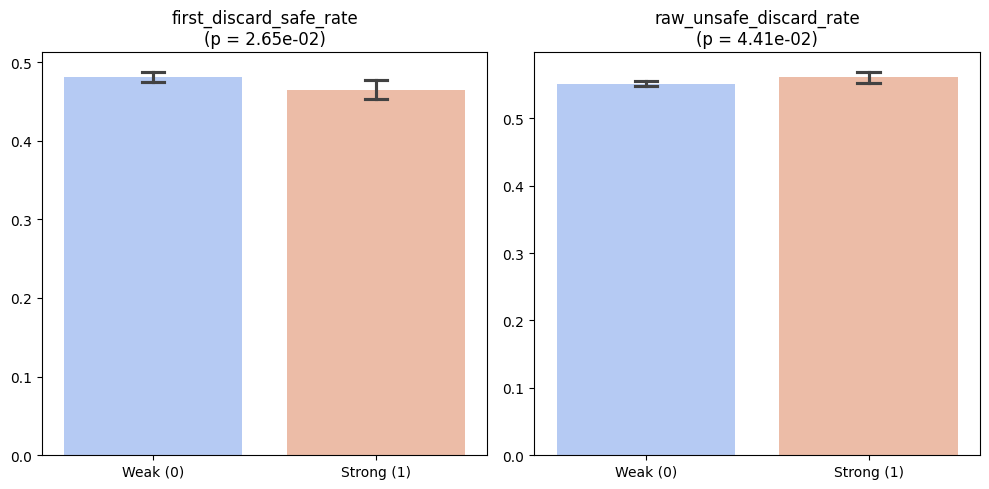

In [4]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 検定する18のミクロ特徴量リスト
micro_features = [
    'first_discard_raw_unsafe_rate', 'first_discard_safe_rate',
    'early_noten_push_rate', 'mid_noten_push_rate', 'late_noten_push_rate',
    'las_desperate_push_rate', 'top_conservative_push_rate', 'flat_situation_push_rate',
    'riichi_dora_mean', 'chasing_riichi_good_shape_rate', 'chasing_riichi_low_value_rate',
    'early_meld_ratio', 'late_meld_ratio', 'meld_dora_ratio',
    'raw_unsafe_discard_rate', 'ryuukyoku_tenpai_rate', 'ryuukyoku_noten_safe_rate'
]

group_strong = micro_dataset_df[micro_dataset_df['target_label'] == 1]
group_weak = micro_dataset_df[micro_dataset_df['target_label'] == 0]

print("==============================================")
print("📊 Welchのt検定による「18大ミクロ戦術」徹底比較")
print("==============================================")
print(f"■ 強（段位18以上）: {len(group_strong)} 試合")
print(f"■ 弱（段位16以下）: {len(group_weak)} 試合\n")

検定結果リスト = []

for feat in micro_features:
    val_strong = group_strong[feat].dropna()
    val_weak = group_weak[feat].dropna()

    # Welchのt検定
    t_stat, p_val = stats.ttest_ind(val_strong, val_weak, equal_var=False)

    mean_strong = val_strong.mean()
    mean_weak = val_weak.mean()
    diff = mean_strong - mean_weak

    # 有意性のラベル付け
    if p_val < 0.01:
        significance = "🌟🌟 極めて有意 (p < 0.01)"
    elif p_val < 0.05:
        significance = "🌟 有意 (p < 0.05)"
    else:
        significance = "❌ 有意差なし"

    検定結果リスト.append({
        '戦術特徴量': feat,
        '強の平均値': mean_strong,
        '弱の平均値': mean_weak,
        '差分(強-弱)': diff,
        'p値': p_val,
        '判定': significance
    })

# データフレーム化し、p値が小さい順（有意差がはっきりしている順）に並び替え
results_df = pd.DataFrame(検定結果リスト).sort_values(by='p値').reset_index(drop=True)

# 綺麗に出力
pd.set_option('display.max_rows', 20)
display(results_df)

# --- 特に有意差が出た上位3つのミクロ戦術の分布可視化 ---
print("\n■ 有意差が最も顕著だった上位3つのミクロ戦術を視覚化します...")
significant_features = results_df[results_df['p値'] < 0.05]['戦術特徴量'].head(3).tolist()

if len(significant_features) > 0:
    fig, axes = plt.subplots(1, len(significant_features), figsize=(5 * len(significant_features), 5))
    if len(significant_features) == 1:
        axes = [axes]

    for i, feat in enumerate(significant_features):
        sns.barplot(
            x='target_label',
            y=feat,
            data=micro_dataset_df,
            ax=axes[i],
            palette='coolwarm',
            capsize=0.1,
            errorbar=('ci', 95),
            hue='target_label',
            legend=False
        )
        axes[i].set_title(f"{feat}\n(p = {results_df.loc[i, 'p値']:.2e})")
        axes[i].set_xticklabels(['Weak (0)', 'Strong (1)'])
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print("※ 有意確率 p < 0.05 を満たす特徴量がありませんでした。")

## LightGBMによるモデル構築と特徴量重要度の可視化

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import lightgbm as lgb

# 1. 説明変数（18のミクロ戦術特徴量）と目的変数
micro_features = [
    'first_discard_raw_unsafe_rate', 'first_discard_safe_rate',
    'early_noten_push_rate', 'mid_noten_push_rate', 'late_noten_push_rate',
    'las_desperate_push_rate', 'top_conservative_push_rate', 'flat_situation_push_rate',
    'riichi_dora_mean', 'chasing_riichi_good_shape_rate', 'chasing_riichi_low_value_rate',
    'early_meld_ratio', 'late_meld_ratio', 'meld_dora_ratio',
    'raw_unsafe_discard_rate', 'ryuukyoku_tenpai_rate', 'ryuukyoku_noten_safe_rate'
]

X_micro = micro_dataset_df[micro_features]
y_micro = micro_dataset_df['target_label']

print("==============================================")
print("🎯 【ミクロ決断モデル】1試合単位でのLightGBM再学習")
print("==============================================")
print(f"■ 説明変数（特徴量）: {X_micro.shape[1]} 次元")
print(f"■ サンプル（試合）数: {X_micro.shape[0]} 試合 (※平滑化なし、1試合単位)\n")

# 2. 5分割交差検証の設定
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds_micro = np.zeros(len(micro_dataset_df))
feature_importances_micro = np.zeros(len(micro_features))

# 3. 交差検証ループの実行
print("--- 5-Fold 交差検証による LightGBM（ミクロ戦術版）の学習を開始します ---")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_micro, y_micro)):
    X_train, y_train = X_micro.iloc[train_idx], y_micro.iloc[train_idx]
    X_val, y_val = X_micro.iloc[val_idx], y_micro.iloc[val_idx]

    # ミクロな行動パターンの複雑な組み合わせを捉えるパラメータ設計
    model = lgb.LGBMClassifier(
        objective='binary',
        class_weight='balanced',
        random_state=42 + fold,
        n_estimators=150,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        verbosity=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=15, verbose=False)]
    )

    oof_preds_micro[val_idx] = model.predict_proba(X_val)[:, 1]
    feature_importances_micro += model.feature_importances_ / skf.n_splits
    print(f"   Fold {fold + 1} 完了")

print("--- 学習完了 ---\n")

# 4. モデルの精度評価
y_pred_micro = (oof_preds_micro >= 0.5).astype(int)

auc_micro = roc_auc_score(y_micro, oof_preds_micro)
accuracy_micro = accuracy_score(y_micro, y_pred_micro)

print("==============================================")
print("🏆 【18大ミクロ戦術・モデル評価結果】")
print("==============================================")
print(f"■ ROC-AUC スコア : {auc_micro:.4f}  (旧5大特徴量モデル: 0.5006)")
print(f"■ 正解率 (Accuracy): {accuracy_micro:.4f}  (旧5大特徴量モデル: 0.5614)\n")
print("■ 詳細レポート:")
print(classification_report(y_micro, y_pred_micro, target_names=['弱 (0)', '強 (1)']))

# 5. 特徴量重要度のデータフレーム化と表示
importance_micro_df = pd.DataFrame({
    'Feature': micro_features,
    'Importance': feature_importances_micro
}).sort_values(by='Importance', ascending=False)

print("\n==============================================")
print("📊 【ミクロ特徴量重要度 ランキング】")
print("==============================================")
for rank, row in enumerate(importance_micro_df.itertuples(), 1):
    print(f"第 {rank} 位: {row.Feature:<35} (重要度: {row.Importance:.2f})")

🎯 【ミクロ決断モデル】1試合単位でのLightGBM再学習
■ 説明変数（特徴量）: 17 次元
■ サンプル（試合）数: 6015 試合 (※平滑化なし、1試合単位)

--- 5-Fold 交差検証による LightGBM（ミクロ戦術版）の学習を開始します ---
   Fold 1 完了
   Fold 2 完了
   Fold 3 完了
   Fold 4 完了
   Fold 5 完了
--- 学習完了 ---

🏆 【18大ミクロ戦術・モデル評価結果】
■ ROC-AUC スコア : 0.4988  (旧5大特徴量モデル: 0.5006)
■ 正解率 (Accuracy): 0.5932  (旧5大特徴量モデル: 0.5614)

■ 詳細レポート:
              precision    recall  f1-score   support

       弱 (0)       0.79      0.66      0.72      4735
       強 (1)       0.21      0.33      0.26      1280

    accuracy                           0.59      6015
   macro avg       0.50      0.50      0.49      6015
weighted avg       0.66      0.59      0.62      6015


📊 【ミクロ特徴量重要度 ランキング】
第 1 位: raw_unsafe_discard_rate             (重要度: 380.60)
第 2 位: early_meld_ratio                    (重要度: 275.20)
第 3 位: flat_situation_push_rate            (重要度: 271.40)
第 4 位: top_conservative_push_rate          (重要度: 267.00)
第 5 位: late_noten_push_rate                (重要度: 259.20)
第 6 位: meld_dora_ratio        

## LightGBMによるモデル構築と特徴量重要度の可視化（平滑化）

🌀 ミクロデータの平滑化（10試合移動平均）の実行
■ 分析対象試合数: 6015 試合
■ 説明変数（ミクロ特徴量）: 17 列
   -> 18大ミクロ戦術のすべてに10試合分の移動平均を適用完了しました。

--- 5-Fold 交差検証による LightGBM（ミクロ平滑化モデル）の学習を開始します ---
   Fold 1 完了
   Fold 2 完了
   Fold 3 完了
   Fold 4 完了
   Fold 5 完了
--- 学習完了 ---

🏆 【平滑化18大ミクロ戦術・モデル評価結果】
■ ROC-AUC スコア : 0.7925  (平滑化なし時: 0.4988)
■ 正解率 (Accuracy): 0.7425  (平滑化なし時: 0.5932)

■ 詳細レポート:
              precision    recall  f1-score   support

       弱 (0)       0.89      0.77      0.82      4735
       強 (1)       0.43      0.66      0.52      1280

    accuracy                           0.74      6015
   macro avg       0.66      0.71      0.67      6015
weighted avg       0.79      0.74      0.76      6015


📊 【新・ミクロ平滑化特徴量重要度 ランキング】
第 1 位: late_meld_ratio                     (重要度: 223.60)
第 2 位: early_noten_push_rate               (重要度: 216.60)
第 3 位: early_meld_ratio                    (重要度: 214.40)
第 4 位: chasing_riichi_low_value_rate       (重要度: 197.00)
第 5 位: chasing_riichi_good_shape_rate      (重要度: 185.60)
第 6 位

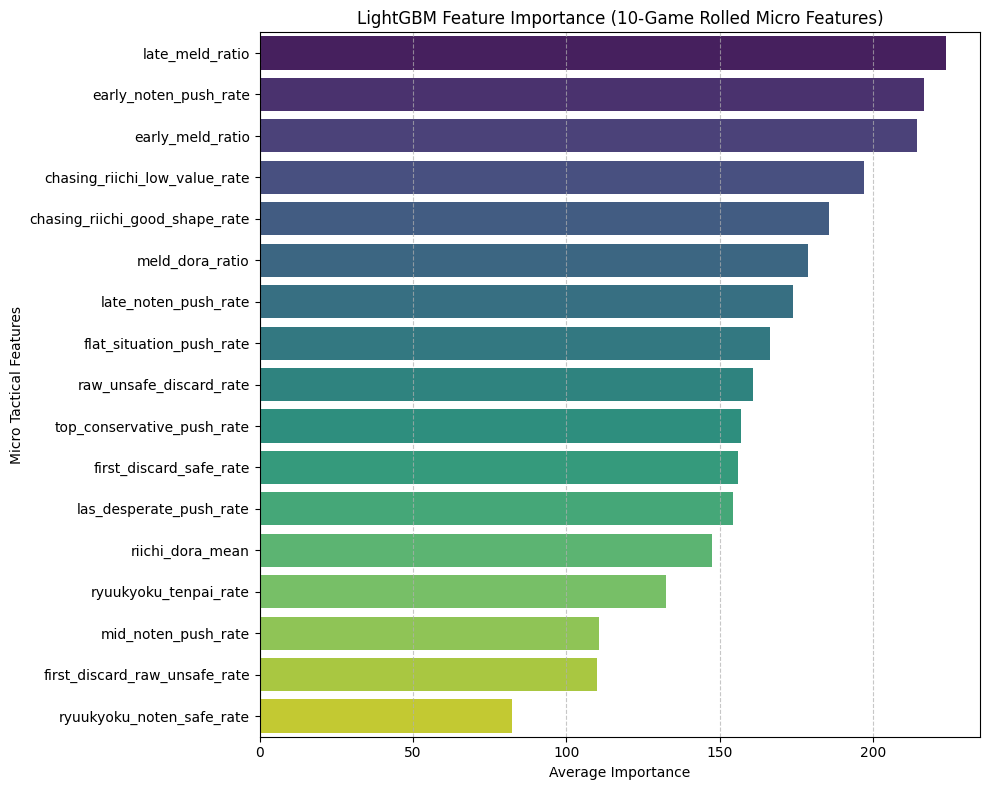

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import lightgbm as lgb

# 1. 18のミクロ戦術特徴量の定義
micro_features = [
    'first_discard_raw_unsafe_rate', 'first_discard_safe_rate',
    'early_noten_push_rate', 'mid_noten_push_rate', 'late_noten_push_rate',
    'las_desperate_push_rate', 'top_conservative_push_rate', 'flat_situation_push_rate',
    'riichi_dora_mean', 'chasing_riichi_good_shape_rate', 'chasing_riichi_low_value_rate',
    'early_meld_ratio', 'late_meld_ratio', 'meld_dora_ratio',
    'raw_unsafe_discard_rate', 'ryuukyoku_tenpai_rate', 'ryuukyoku_noten_safe_rate'
]

# 2. データのコピーと「10試合移動平均（平滑化）」の適用
# ※ 牌譜が時系列順（file_id 順）にソートされている状態を維持して平滑化します
rolled_micro_df = micro_dataset_df.copy()
for feat in micro_features:
    rolled_micro_df[feat] = rolled_micro_df[feat].rolling(window=10, min_periods=1).mean()

# 欠損値補完（念のため）
rolled_micro_df.fillna(rolled_micro_df.mean(numeric_only=True), inplace=True)

# 3. 説明変数(X)と目的変数(y)の設定
X_rolled = rolled_micro_df[micro_features]
y_rolled = rolled_micro_df['target_label']

print("==============================================")
print("🌀 ミクロデータの平滑化（10試合移動平均）の実行")
print("==============================================")
print(f"■ 分析対象試合数: {X_rolled.shape[0]} 試合")
print(f"■ 説明変数（ミクロ特徴量）: {X_rolled.shape[1]} 列")
print("   -> 18大ミクロ戦術のすべてに10試合分の移動平均を適用完了しました。\n")

# 4. 5分割交差検証の設定
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds_micro_rolled = np.zeros(len(rolled_micro_df))
feature_importances_micro_rolled = np.zeros(len(micro_features))

# 5. 交差検証ループの実行
print("--- 5-Fold 交差検証による LightGBM（ミクロ平滑化モデル）の学習を開始します ---")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_rolled, y_rolled)):
    X_train, y_train = X_rolled.iloc[train_idx], y_rolled.iloc[train_idx]
    X_val, y_val = X_rolled.iloc[val_idx], y_rolled.iloc[val_idx]

    model = lgb.LGBMClassifier(
        objective='binary',
        class_weight='balanced',
        random_state=42 + fold,
        n_estimators=150,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        verbosity=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=15, verbose=False)]
    )

    oof_preds_micro_rolled[val_idx] = model.predict_proba(X_val)[:, 1]
    feature_importances_micro_rolled += model.feature_importances_ / skf.n_splits
    print(f"   Fold {fold + 1} 完了")

print("--- 学習完了 ---\n")

# 6. モデルの精度評価
y_pred_micro_rolled = (oof_preds_micro_rolled >= 0.5).astype(int)

auc_micro_rolled = roc_auc_score(y_rolled, oof_preds_micro_rolled)
accuracy_micro_rolled = accuracy_score(y_rolled, y_pred_micro_rolled)

print("==============================================")
print("🏆 【平滑化18大ミクロ戦術・モデル評価結果】")
print("==============================================")
print(f"■ ROC-AUC スコア : {auc_micro_rolled:.4f}  (平滑化なし時: 0.4988)")
print(f"■ 正解率 (Accuracy): {accuracy_micro_rolled:.4f}  (平滑化なし時: 0.5932)\n")
print("■ 詳細レポート:")
print(classification_report(y_rolled, y_pred_micro_rolled, target_names=['弱 (0)', '強 (1)']))

# 7. 特徴量重要度のデータフレーム化と表示
importance_micro_rolled_df = pd.DataFrame({
    'Feature': micro_features,
    'Importance': feature_importances_micro_rolled
}).sort_values(by='Importance', ascending=False)

print("\n==============================================")
print("📊 【新・ミクロ平滑化特徴量重要度 ランキング】")
print("==============================================")
for rank, row in enumerate(importance_micro_rolled_df.itertuples(), 1):
    print(f"第 {rank} 位: {row.Feature:<35} (重要度: {row.Importance:.2f})")

# 8. 特徴量重要度の可視化
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_micro_rolled_df,
    hue='Feature',
    palette='viridis',
    legend=False
)
plt.title('LightGBM Feature Importance (10-Game Rolled Micro Features)')
plt.xlabel('Average Importance')
plt.ylabel('Micro Tactical Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
print("グラフを描写します...")
plt.show()

##序盤・中盤・終盤の押し率の可視化

/tmp/ipykernel_594/2654220413.py:58: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


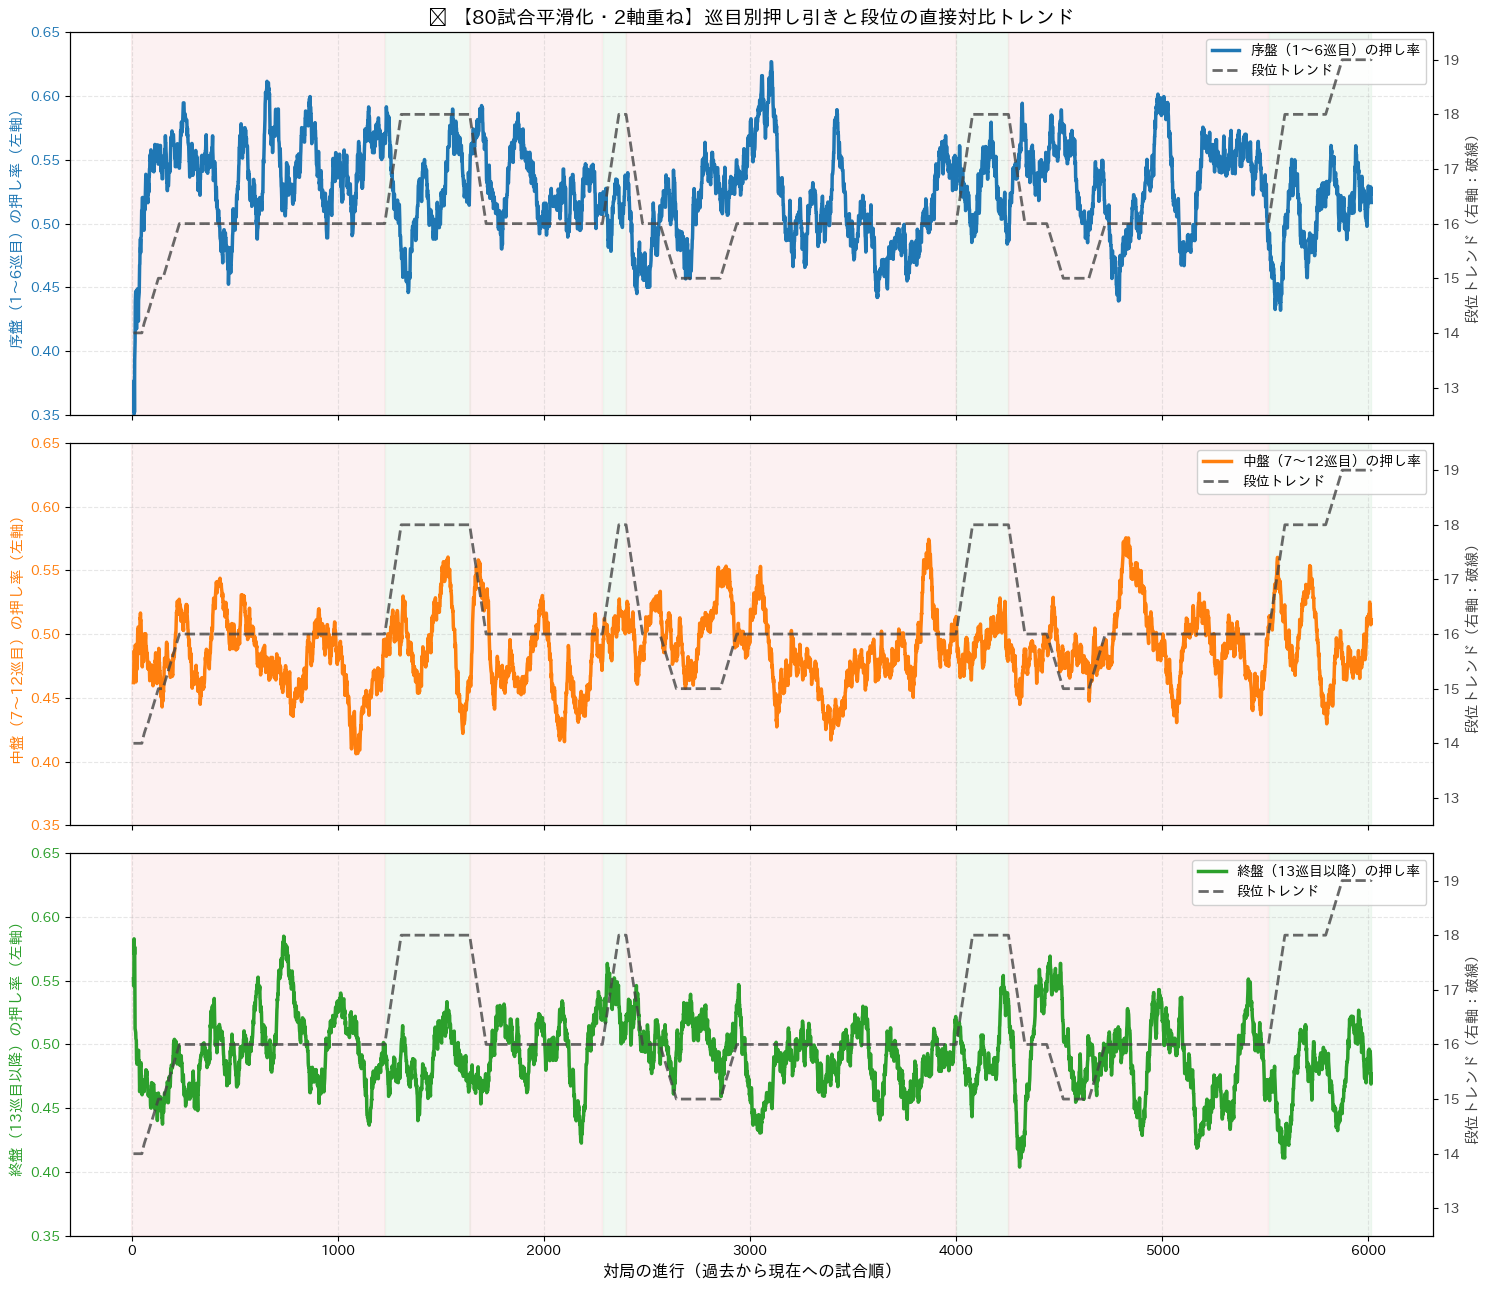

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

# 1. データの整理と80試合移動平均（リアルな波を残す）の算出
trend_df = micro_dataset_df.copy()
trend_df = trend_df.sort_values('file_id').reset_index(drop=True)

window_size = 80
trend_df['序盤の押し率'] = trend_df['early_noten_push_rate'].rolling(window=window_size, min_periods=10).mean()
trend_df['中盤の押し率'] = trend_df['mid_noten_push_rate'].rolling(window=window_size, min_periods=10).mean()
trend_df['終盤の押し率'] = trend_df['late_noten_push_rate'].rolling(window=window_size, min_periods=10).mean()

# 段位も同じ80試合で平滑化
trend_df['段位トレンド'] = trend_df['shobon_dan'].rolling(window=window_size, min_periods=10).mean()

strong_periods = trend_df['shobon_dan'] >= 18
weak_periods = trend_df['shobon_dan'] <= 16

# 2. 3段構成で、それぞれに段位を重ね合わせる（ツインアキシス）
fig, axes = plt.subplots(3, 1, figsize=(15, 13), sharex=True)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels = ['序盤（1〜6巡目）の押し率', '中盤（7〜12巡目）の押し率', '終盤（13巡目以降）の押し率']
targets = ['序盤の押し率', '中盤の押し率', '終盤の押し率']

for i, ax1 in enumerate(axes):
    # 背景の色分け（薄い緑＝好調期、薄い赤＝不調期）
    ax1.fill_between(trend_df.index, 0, 1, where=strong_periods, color='#d4edda', alpha=0.35, transform=ax1.get_xaxis_transform())
    ax1.fill_between(trend_df.index, 0, 1, where=weak_periods, color='#f8d7da', alpha=0.35, transform=ax1.get_xaxis_transform())

    # 軸①（左側）：押し率（カラー）
    line_push = ax1.plot(trend_df.index, trend_df[targets[i]], color=colors[i], linewidth=2.5, label=labels[i])
    ax1.set_ylim(0.35, 0.65)
    ax1.set_ylabel(labels[i] + '（左軸）', color=colors[i], fontweight='bold', fontsize=11)
    ax1.tick_params(axis='y', labelcolor=colors[i])
    ax1.grid(True, linestyle='--', alpha=0.3)

    # 軸②（右側）：段位トレンド（黒の破線）
    ax2 = ax1.twinx()
    line_dan = ax2.plot(trend_df.index, trend_df['段位トレンド'], color='#444444', linestyle='--', linewidth=2, alpha=0.8, label='段位トレンド')
    ax2.set_ylim(12.5, 19.5) # 段位が変動するレンジ（13〜18付近）に最適化
    ax2.set_ylabel('段位トレンド（右軸：破線）', color='#444444', fontweight='bold', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='#444444')

    # 凡例を統合
    lines = line_push + line_dan
    labs = [l.get_label() for l in lines]
    ax1.legend(lines, labs, loc='upper right', framealpha=0.9)

    if i == 0:
        ax1.set_title('📈 【80試合平滑化・2軸重ね】巡目別押し引きと段位の直接対比トレンド', fontsize=14, fontweight='bold')

# 最下段のみ横軸ラベル
axes[-1].set_xlabel('対局の進行（過去から現在への試合順）', fontsize=12)

plt.tight_layout()
plt.show()

##点数状況別の押し引き × 段位トレンド（80試合平滑化）

/tmp/ipykernel_594/4198216905.py:54: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


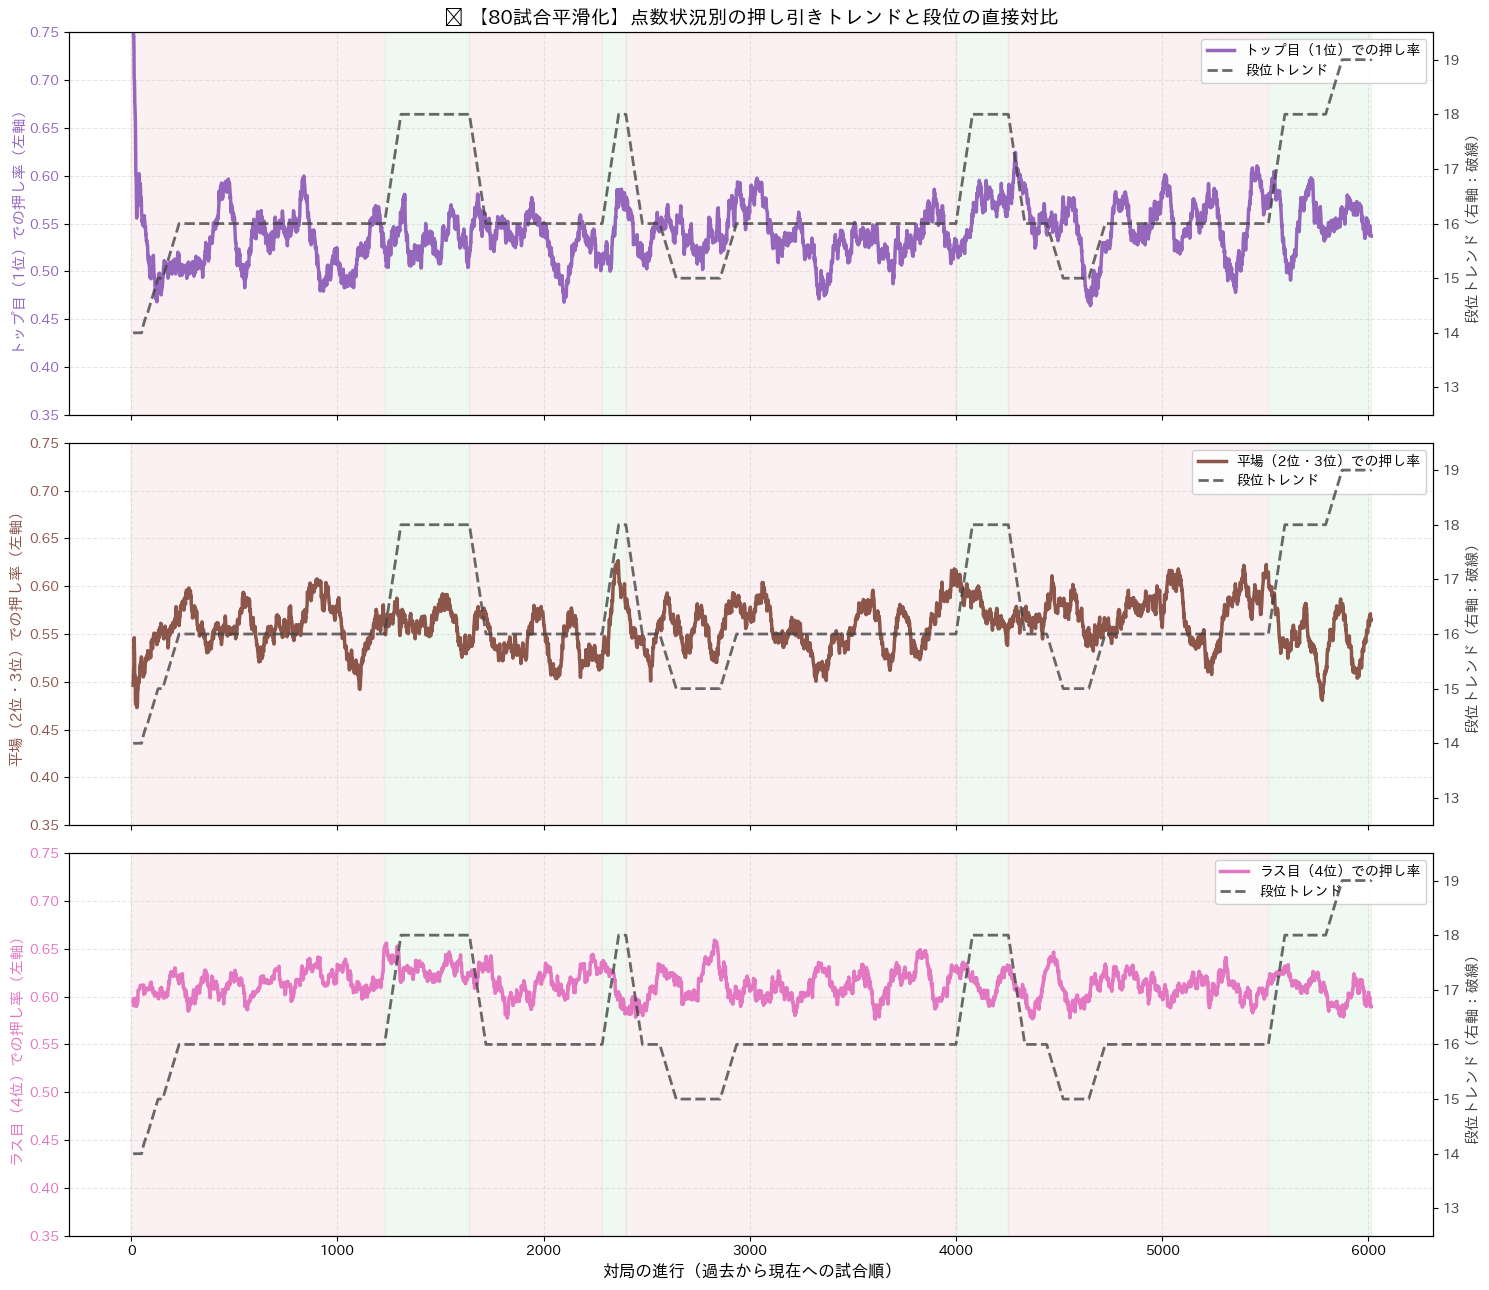

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

# 1. データの整理と80試合移動平均の算出
trend_df = micro_dataset_df.copy()
trend_df = trend_df.sort_values('file_id').reset_index(drop=True)

window_size = 80
trend_df['トップ目の押し率'] = trend_df['top_conservative_push_rate'].rolling(window=window_size, min_periods=10).mean()
trend_df['平場の押し率'] = trend_df['flat_situation_push_rate'].rolling(window=window_size, min_periods=10).mean()
trend_df['ラス目の押し率'] = trend_df['las_desperate_push_rate'].rolling(window=window_size, min_periods=10).mean()
trend_df['段位トレンド'] = trend_df['shobon_dan'].rolling(window=window_size, min_periods=10).mean()

strong_periods = trend_df['shobon_dan'] >= 18
weak_periods = trend_df['shobon_dan'] <= 16

# 2. 3段構成で段位を重ね合わせる（点数状況別）
fig, axes = plt.subplots(3, 1, figsize=(15, 13), sharex=True)

colors = ['#9467bd', '#8c564b', '#e377c2']
labels = ['トップ目（1位）での押し率', '平場（2位・3位）での押し率', 'ラス目（4位）での押し率']
targets = ['トップ目の押し率', '平場の押し率', 'ラス目の押し率']

for i, ax1 in enumerate(axes):
    # 背景色（薄い緑＝好調期、薄い赤＝不調期）
    ax1.fill_between(trend_df.index, 0, 1, where=strong_periods, color='#d4edda', alpha=0.35, transform=ax1.get_xaxis_transform())
    ax1.fill_between(trend_df.index, 0, 1, where=weak_periods, color='#f8d7da', alpha=0.35, transform=ax1.get_xaxis_transform())

    # 左軸：押し率（カラー）
    line_push = ax1.plot(trend_df.index, trend_df[targets[i]], color=colors[i], linewidth=2.5, label=labels[i])
    ax1.set_ylim(0.35, 0.75)  # ラス目の必死の押し（高数値）を考慮して上限を0.75に調整
    ax1.set_ylabel(labels[i] + '（左軸）', color=colors[i], fontweight='bold', fontsize=11)
    ax1.tick_params(axis='y', labelcolor=colors[i])
    ax1.grid(True, linestyle='--', alpha=0.3)

    # 右軸：段位トレンド（黒の破線）
    ax2 = ax1.twinx()
    line_dan = ax2.plot(trend_df.index, trend_df['段位トレンド'], color='#444444', linestyle='--', linewidth=2, alpha=0.8, label='段位トレンド')
    ax2.set_ylim(12.5, 19.5)
    ax2.set_ylabel('段位トレンド（右軸：破線）', color='#444444', fontweight='bold', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='#444444')

    # 凡例統合
    lines = line_push + line_dan
    labs = [l.get_label() for l in lines]
    ax1.legend(lines, labs, loc='upper right', framealpha=0.9)

    if i == 0:
        ax1.set_title('📈 【80試合平滑化】点数状況別の押し引きトレンドと段位の直接対比', fontsize=14, fontweight='bold')

axes[-1].set_xlabel('対局の進行（過去から現在への試合順）', fontsize=12)
plt.tight_layout()
plt.show()

##仕掛け（鳴き）のスピードと質 × 段位トレンド（80試合平滑化）

/tmp/ipykernel_594/3176183158.py:57: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


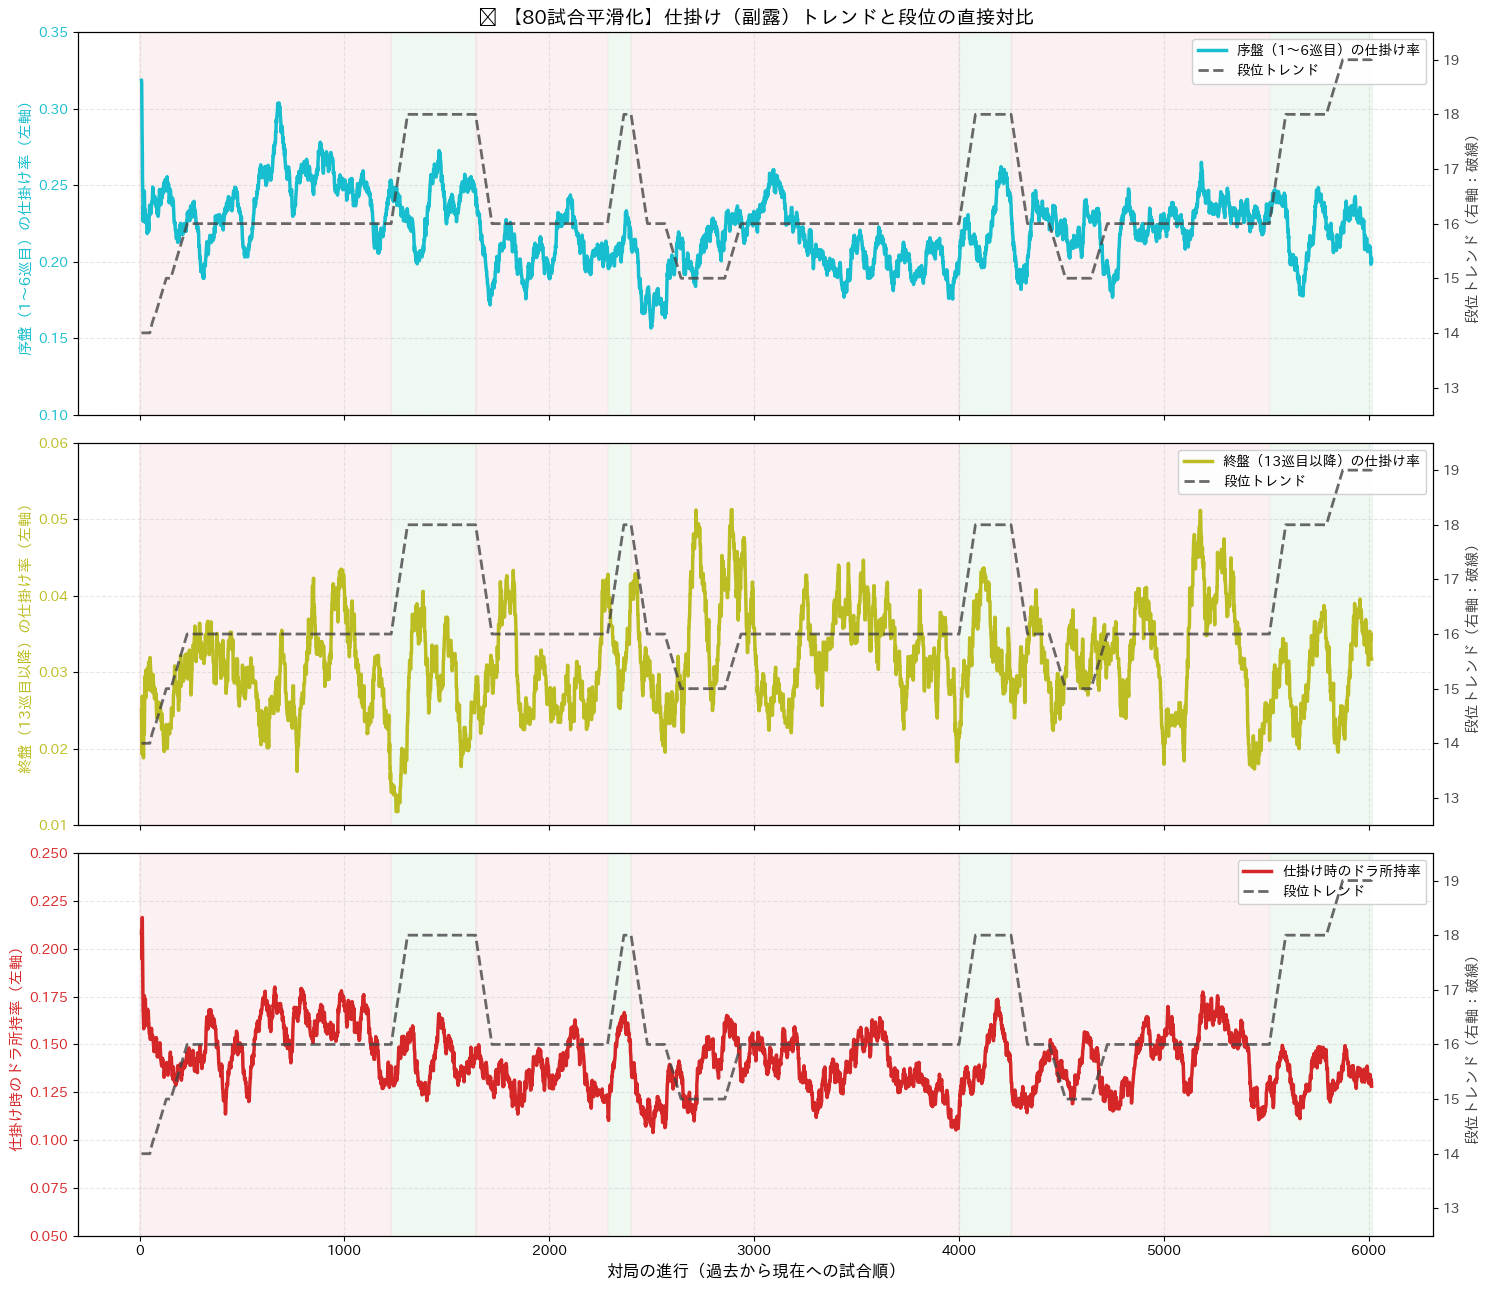

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

# 1. データの整理と80試合移動平均の算出
trend_df = micro_dataset_df.copy()
trend_df = trend_df.sort_values('file_id').reset_index(drop=True)

window_size = 80
trend_df['序盤の仕掛け率'] = trend_df['early_meld_ratio'].rolling(window=window_size, min_periods=10).mean()
trend_df['終盤の仕掛け率'] = trend_df['late_meld_ratio'].rolling(window=window_size, min_periods=10).mean()
trend_df['ドラ持ち仕掛け率'] = trend_df['meld_dora_ratio'].rolling(window=window_size, min_periods=10).mean()
trend_df['段位トレンド'] = trend_df['shobon_dan'].rolling(window=window_size, min_periods=10).mean()

strong_periods = trend_df['shobon_dan'] >= 18
weak_periods = trend_df['shobon_dan'] <= 16

# 2. 3段構成で段位を重ね合わせる（仕掛け）
fig, axes = plt.subplots(3, 1, figsize=(15, 13), sharex=True)

colors = ['#17becf', '#bcbd22', '#d62728']
labels = ['序盤（1〜6巡目）の仕掛け率', '終盤（13巡目以降）の仕掛け率', '仕掛け時のドラ所持率']
targets = ['序盤の仕掛け率', '終盤の仕掛け率', 'ドラ持ち仕掛け率']

# 鳴き率は数値のレンジが大きく異なるため、個別に縦軸の範囲（ylim）を設定します
ylims = [(0.10, 0.35), (0.01, 0.06), (0.05, 0.25)]

for i, ax1 in enumerate(axes):
    # 背景色（薄い緑＝好調期、薄い赤＝不調期）
    ax1.fill_between(trend_df.index, 0, 1, where=strong_periods, color='#d4edda', alpha=0.35, transform=ax1.get_xaxis_transform())
    ax1.fill_between(trend_df.index, 0, 1, where=weak_periods, color='#f8d7da', alpha=0.35, transform=ax1.get_xaxis_transform())

    # 左軸：仕掛け関連（カラー）
    line_meld = ax1.plot(trend_df.index, trend_df[targets[i]], color=colors[i], linewidth=2.5, label=labels[i])
    ax1.set_ylim(ylims[i])
    ax1.set_ylabel(labels[i] + '（左軸）', color=colors[i], fontweight='bold', fontsize=11)
    ax1.tick_params(axis='y', labelcolor=colors[i])
    ax1.grid(True, linestyle='--', alpha=0.3)

    # 右軸：段位トレンド（黒の破線）
    ax2 = ax1.twinx()
    line_dan = ax2.plot(trend_df.index, trend_df['段位トレンド'], color='#444444', linestyle='--', linewidth=2, alpha=0.8, label='段位トレンド')
    ax2.set_ylim(12.5, 19.5)
    ax2.set_ylabel('段位トレンド（右軸：破線）', color='#444444', fontweight='bold', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='#444444')

    # 凡例統合
    lines = line_meld + line_dan
    labs = [l.get_label() for l in lines]
    ax1.legend(lines, labs, loc='upper right', framealpha=0.9)

    if i == 0:
        ax1.set_title('⚡ 【80試合平滑化】仕掛け（副露）トレンドと段位の直接対比', fontsize=14, fontweight='bold')

axes[-1].set_xlabel('対局の進行（過去から現在への試合順）', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. 80試合移動平均（トレンド）データの作成
trend_df = micro_dataset_df.copy()
trend_df = trend_df.sort_values('file_id').reset_index(drop=True)

# 調査対象の主要ミクロ戦術特徴量
target_features = [
    # 巡目別押し引き
    'early_noten_push_rate', 'mid_noten_push_rate', 'late_noten_push_rate',
    # 点数状況別押し引き
    'top_conservative_push_rate', 'flat_situation_push_rate', 'las_desperate_push_rate',
    # 仕掛けのミクロ
    'early_meld_ratio', 'late_meld_ratio', 'meld_dora_ratio'
]

# 80試合平滑化（トレンド）を適用
window_size = 80
smooth_df = pd.DataFrame()
smooth_df['shobon_dan_smooth'] = trend_df['shobon_dan'].rolling(window=window_size, min_periods=10).mean()

for feat in target_features:
    smooth_df[f'{feat}_smooth'] = trend_df[feat].rolling(window=window_size, min_periods=10).mean()

# 欠損値（最初の数試合など）を除外して相関を計算
smooth_df_clean = smooth_df.dropna()

correlation_results = []

for feat in target_features:
    x = smooth_df_clean[f'{feat}_smooth']
    y = smooth_df_clean['shobon_dan_smooth']

    # 相関係数とp値を算出
    corr, p_val = stats.pearsonr(x, y)

    # 相関の強さの解釈
    if abs(corr) >= 0.7:
        strength = "🔴🔴 非常に強い相関"
    elif abs(corr) >= 0.4:
        strength = "🔴 強い相関"
    elif abs(corr) >= 0.2:
        strength = "🟡 弱い相関（連動あり）"
    else:
        strength = "⚪ ほとんど無相関"

    correlation_results.append({
        '戦術カテゴリー': '巡目別押し引き' if 'noten_push' in feat else ('点数状況別押し引き' if 'push_rate' in feat or 'situation' in feat else '仕掛けのミクロ'),
        'ミクロ戦術特徴量': feat,
        '相関係数 (r)': corr,
        '有意確率 (p値)': p_val,
        '相関の強さ': strength,
        '段位との関係': "段位が上がるとこの行動が【増える】" if corr > 0 else "段位が上がるとこの行動が【減る】"
    })

# データフレームにまとめて表示
corr_df = pd.DataFrame(correlation_results).sort_values(by='相関係数 (r)', key=abs, ascending=False).reset_index(drop=True)

print("==========================================================================")
print("📊 【数値で証明】80試合トレンドにおけるミクロ戦術と段位の連動性（相関分析）")
print("==========================================================================")
display(corr_df)

📊 【数値で証明】80試合トレンドにおけるミクロ戦術と段位の連動性（相関分析）


,戦術カテゴリー,ミクロ戦術特徴量,相関係数 (r),有意確率 (p値),相関の強さ,段位との関係
0,点数状況別押し引き,top_conservative_push_rate,0.186408,4.284492e-48,⚪ ほとんど無相関,段位が上がるとこの行動が【増える】
1,巡目別押し引き,mid_noten_push_rate,0.089467,3.757565e-12,⚪ ほとんど無相関,段位が上がるとこの行動が【増える】
2,仕掛けのミクロ,meld_dora_ratio,-0.069686,6.444291e-08,⚪ ほとんど無相関,段位が上がるとこの行動が【減る】
3,巡目別押し引き,early_noten_push_rate,-0.067126,1.919581e-07,⚪ ほとんど無相関,段位が上がるとこの行動が【減る】
4,巡目別押し引き,late_noten_push_rate,-0.065543,3.697890e-07,⚪ ほとんど無相関,段位が上がるとこの行動が【減る】
5,仕掛けのミクロ,early_meld_ratio,0.049343,1.304983e-04,⚪ ほとんど無相関,段位が上がるとこの行動が【増える】
6,仕掛けのミクロ,late_meld_ratio,-0.042811,9.046381e-04,⚪ ほとんど無相関,段位が上がるとこの行動が【減る】
7,点数状況別押し引き,las_desperate_push_rate,0.038448,2.881031e-03,⚪ ほとんど無相関,段位が上がるとこの行動が【増える】
8,点数状況別押し引き,flat_situation_push_rate,0.038006,3.220696e-03,⚪ ほとんど無相関,段位が上がるとこの行動が【増える】


##SHAP値の確認

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


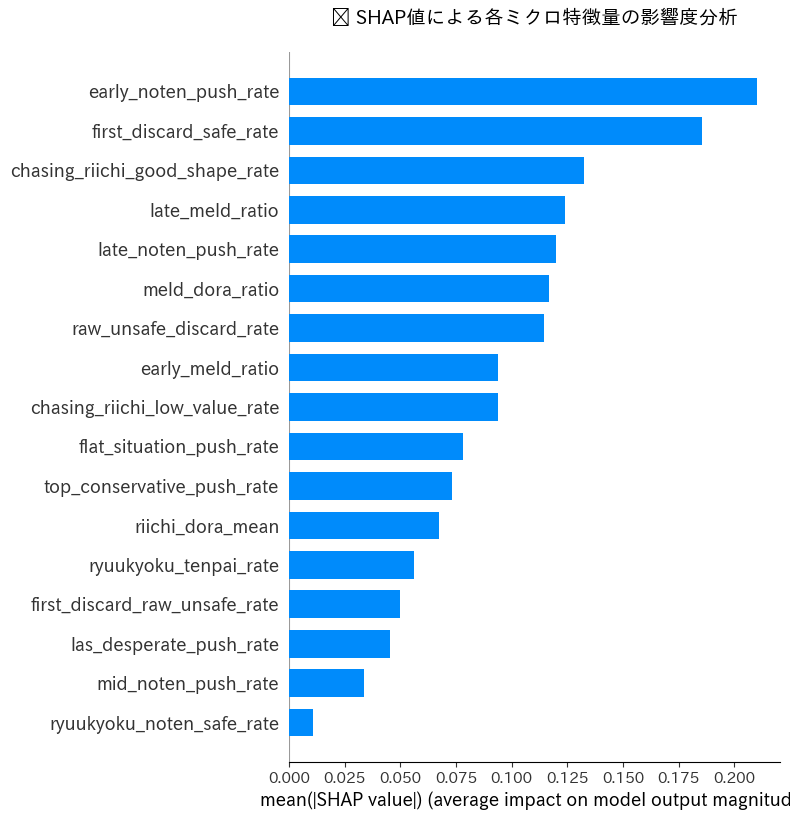

/tmp/ipykernel_594/3214119748.py:62: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


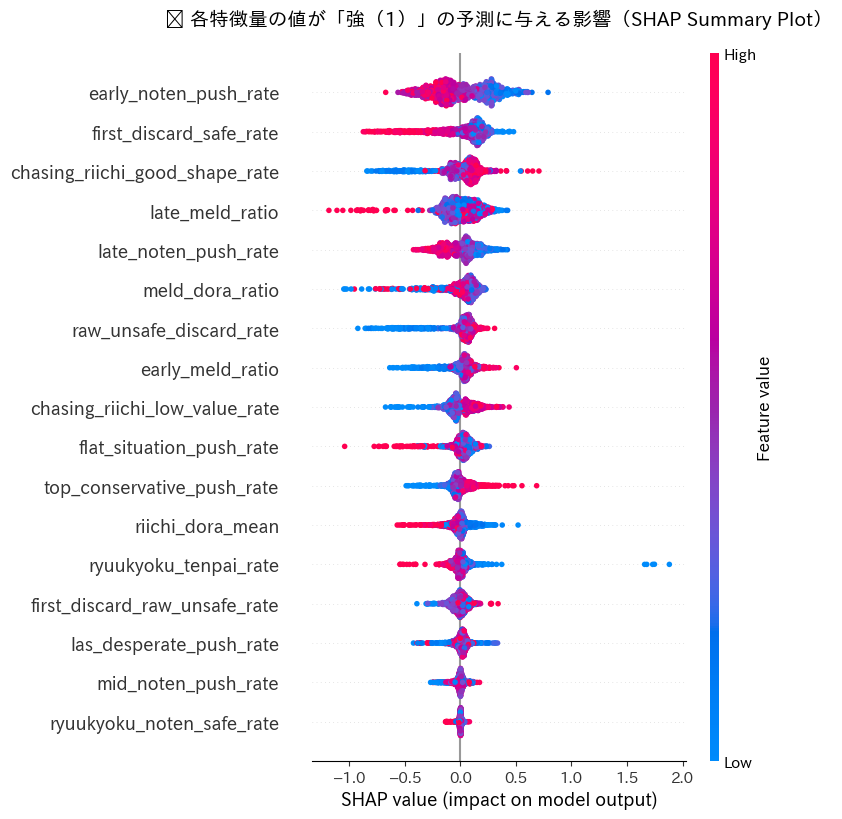

In [17]:
# 1. SHAPライブラリのインストール
!pip install shap -q

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import train_test_split

# 2. データの準備（10試合移動平均を適用したデータを使用します）
trend_df = micro_dataset_df.copy()
trend_df = trend_df.sort_values('file_id').reset_index(drop=True)

micro_features = [
    'first_discard_raw_unsafe_rate', 'first_discard_safe_rate',
    'early_noten_push_rate', 'mid_noten_push_rate', 'late_noten_push_rate',
    'las_desperate_push_rate', 'top_conservative_push_rate', 'flat_situation_push_rate',
    'riichi_dora_mean', 'chasing_riichi_good_shape_rate', 'chasing_riichi_low_value_rate',
    'early_meld_ratio', 'late_meld_ratio', 'meld_dora_ratio',
    'raw_unsafe_discard_rate', 'ryuukyoku_tenpai_rate', 'ryuukyoku_noten_safe_rate'
]

# 10試合移動平均を適用
X_rolled = trend_df[micro_features].copy()
for feat in micro_features:
    X_rolled[feat] = X_rolled[feat].rolling(window=10, min_periods=1).mean()

# 欠損値補完
X_rolled.fillna(X_rolled.mean(numeric_only=True), inplace=True)
y_rolled = trend_df['target_label']

# 3. テストデータの分割とモデルの簡易学習（SHAP計算用）
X_train, X_test, y_train, y_test = train_test_split(X_rolled, y_rolled, test_size=0.2, random_state=42, stratify=y_rolled)

shap_model = lgb.LGBMClassifier(
    objective='binary',
    class_weight='balanced',
    random_state=42,
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    verbosity=-1
)
shap_model.fit(X_train, y_train)

# 4. SHAP値の計算（TreeExplainerを使用）
explainer = shap.TreeExplainer(shap_model)
shap_values = explainer(X_test)

# 5. SHAP Summary Plot（ドットプロット）の描画
plt.figure(figsize=(10, 8))
# 日本語化ライブラリを入れているのでフォントが適用されますが、SHAP内の文字化けを防ぐためフォントサイズを調整
plt.title("🔑 SHAP値による各ミクロ特徴量の影響度分析", fontsize=14, fontweight='bold', pad=20)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 9))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("🔑 各特徴量の値が「強（1）」の予測に与える影響（SHAP Summary Plot）", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()